# Dynamic Pricing Model Using Thompson Sampling

This notebook implements **dynamic pricing** for a single product using **Thompson sampling**.  
It shows how a smart algorithm can automatically choose the best price by trying different prices over time and learning which one gives the most revenue.

### What this project does

- We assume a shop sells **one product (SKU)** with a few fixed price levels (for example, ₹100, ₹120, ₹150).  
- The shop starts with **no sales data** and does not know which price will sell best.  
- We use **Thompson sampling** to:
  - Suggest a price at each time step.  
  - Learn from sales and gradually converge to the **best price**.

### How it works (simple explanation)

- For each price, we keep a **probability distribution** (like a belief about how good that price is).  
- At each step, the algorithm:
  - Samples from these distributions.  
  - Picks the price that looks best **right now**.  
  - Updates the distributions using the real sales (this is the **learning** part).  
- Over time, it **explores** (tries other prices a bit) and **exploits** (uses the best‑known price more often).

### What you can see in the notebook

- A **demand simulator** that generates fake sales data.  
- Plots showing:
  - How often each price is chosen.  
  - How the estimated revenue changes over time.  
  - How the algorithm stabilizes at the best price.

### Usage and next steps

- This prototype can be adapted to build a **real dynamic pricing system** for e‑commerce or ticketing platforms.  
- You can extend it by adding:
  - Multiple products.  
  - Inventory constraints.  
  - Custom business rules (minimum/maximum price, discounts, etc.).

### References
1. Ferreira K., Simchi-Levi D., and Wang H. -- Online Network Revenue Management Using Thompson Sampling, November 2017

In [11]:
import numpy as np
from tabulate import tabulate
from scipy.optimize import linprog
import scipy.stats as stats 
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.animation as animation

np.set_printoptions(precision=2)

def tabprint(msg, A):
    print(msg)
    print(tabulate(A, tablefmt="fancy_grid"))
    
plt.rcParams.update({'font.family':'Candara', 'font.serif':['Candara']})
plt.rcParams.update({'pdf.fonttype': 'truetype', 'font.size': 18})

# Step 1: Determine Optimal Prices Using Numerical Optimization

In [12]:
# Find the optimal distribution of prices (price probabilities) given fixed price levels, 
# corresponding demand levels, and available product inventory.
# 
# Inputs:
#   prices, demands, and revenues are vectors (i-th element corresponds to i-th price level)
#   inventory is a scalar (number of available units)
def optimal_price_probabilities(prices, demands, inventory):   
    revenues = np.multiply(prices, demands)
    
    L = len(prices)
    M = np.full([1, L], 1)
    B = [[1]]
    Df = [demands]

    res = linprog(-np.array(revenues).flatten(), 
                  A_eq=M, 
                  b_eq=B, 
                  A_ub=Df, 
                  b_ub=np.array([inventory]), 
                  bounds=(0, None))

    price_prob = np.array(res.x).reshape(1, L).flatten()
    return price_prob

In [17]:
# Optimization procedure test
prices = [1.99, 2.49, 2.99, 3.49, 3.99, 4.49]
demands = list(map(lambda p: 50 - 7*p, prices))
revenues = np.multiply(prices, demands)
print(demands)
print(revenues)
print(optimal_price_probabilities(prices, demands, 60))

[36.07, 32.57, 29.07, 25.57, 22.07, 18.57]
[71.78 81.1  86.92 89.24 88.06 83.38]
[0. 0. 0. 1. 0. 0.]


# Step 2: Optimize Prices Dynamically Using Thompson Sampling 

In [18]:
prices = [1.99, 2.49, 2.99, 3.49, 3.99, 4.49]

# Hidden (true) demand parameters - a linear demand function is assumed
demand_a = 50
demand_b = 7

# prior distribution for each price - gamma(α, β)
θ = []
for p in prices:
    θ.append({'price': p, 'alpha': 30.00, 'beta': 1.00, 'mean': 30.00})

def gamma(alpha, beta):
    shape = alpha
    scale = 1/beta
    return np.random.gamma(shape, scale)

def sample_demand(price):
    demand = demand_a - demand_b * price
    return np.random.poisson(demand, 1)[0]

def sample_demands_from_model(θ):
    return list(map(lambda v: gamma(v['alpha'], v['beta']), θ))
        
T = 50
history = []
for t in range(0, T):              # simulation loop
    demands = sample_demands_from_model(θ)
    print(tabulate(np.array(θ), tablefmt="fancy_grid"))
    
    print("demands = ", np.array(demands))
    
    price_probs = optimal_price_probabilities(prices, demands, 60)
    
    # select one best price
    price_index_t = np.random.choice(len(prices), 1, p=price_probs)[0]
    price_t = prices[price_index_t]
    
    # sell at the selected price and observe demand
    demand_t = sample_demand(price_t)
    print('selected price %.2f => demand %.2f, revenue %.2f' % (price_t, demand_t, demand_t*price_t))
    
    theta_trace = []
    for v in θ:
        theta_trace.append(v.copy())
    history.append([price_t, demand_t, demand_t*price_t, theta_trace])
    
    # update model parameters
    v = θ[price_index_t]
    v['alpha'] = v['alpha'] + demand_t
    v['beta'] = v['beta'] + 1
    v['mean'] = v['alpha'] / v['beta']
    
    print("")

╒══════╤════╤═══╤════╕
│ 1.99 │ 30 │ 1 │ 30 │
├──────┼────┼───┼────┤
│ 2.49 │ 30 │ 1 │ 30 │
├──────┼────┼───┼────┤
│ 2.99 │ 30 │ 1 │ 30 │
├──────┼────┼───┼────┤
│ 3.49 │ 30 │ 1 │ 30 │
├──────┼────┼───┼────┤
│ 3.99 │ 30 │ 1 │ 30 │
├──────┼────┼───┼────┤
│ 4.49 │ 30 │ 1 │ 30 │
╘══════╧════╧═══╧════╛
demands =  [24.94 38.89 32.49 37.7  31.14 32.6 ]
selected price 4.49 => demand 17.00, revenue 76.33

╒══════╤════╤═══╤══════╕
│ 1.99 │ 30 │ 1 │ 30   │
├──────┼────┼───┼──────┤
│ 2.49 │ 30 │ 1 │ 30   │
├──────┼────┼───┼──────┤
│ 2.99 │ 30 │ 1 │ 30   │
├──────┼────┼───┼──────┤
│ 3.49 │ 30 │ 1 │ 30   │
├──────┼────┼───┼──────┤
│ 3.99 │ 30 │ 1 │ 30   │
├──────┼────┼───┼──────┤
│ 4.49 │ 47 │ 2 │ 23.5 │
╘══════╧════╧═══╧══════╛
demands =  [24.76 26.83 32.74 29.24 33.4  21.74]
selected price 3.99 => demand 14.00, revenue 55.86

╒══════╤════╤═══╤══════╕
│ 1.99 │ 30 │ 1 │ 30   │
├──────┼────┼───┼──────┤
│ 2.49 │ 30 │ 1 │ 30   │
├──────┼────┼───┼──────┤
│ 2.99 │ 30 │ 1 │ 30   │
├──────┼────┼───┼──────┤

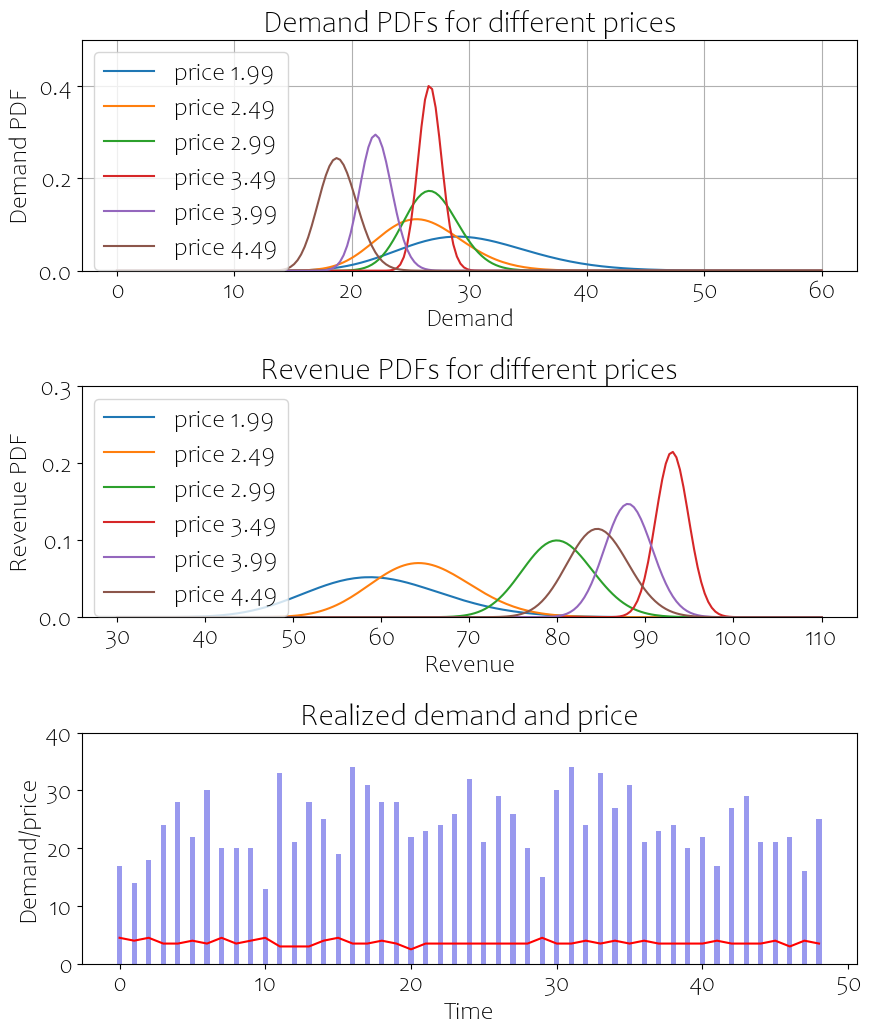

In [19]:
def visualize_snapshot(t):
    plt.subplot(3, 1, 1)
    plt.xlabel('Demand')
    plt.ylabel('Demand PDF')
    plt.title('Demand PDFs for different prices')
    x = np.linspace(0, 60, 200) 
    for i, params in enumerate(history[t][3]):
        y = stats.gamma.pdf(x, a=params['alpha'], scale=1.0/params['beta']) 
        plt.plot(x, y, "-", label='price %.2f' % params['price']) 
    plt.legend(loc='upper left')
    plt.ylim([0, 0.5])
    plt.grid(True)

    plt.subplot(3, 1, 2)
    plt.xlabel('Revenue')
    plt.ylabel('Revenue PDF')
    plt.title('Revenue PDFs for different prices')
    x = np.linspace(30, 110, 200) 
    for i, params in enumerate(history[t][3]):
        y = stats.gamma.pdf(x, a=params['alpha']*params['price'], scale=1.0/params['beta']) 
        plt.plot(x, y, "-", label='price %.2f' % params['price']) 
    plt.legend(loc='upper left')
    plt.ylim([0, 0.3])
    
    plt.subplot(3, 1, 3)
    plt.xlabel('Time')
    plt.ylabel('Demand/price')
    plt.title('Realized demand and price')
    prices = [h[0] for h in history]
    demands = [h[1] for h in history]
    plt.plot(range(0, t+1), np.array(prices)[0:t+1], 'r-') 
    plt.bar(range(0, T-1), np.pad(np.array(demands)[0:t+1], (0, T-2-t), 'constant'), 0.35, color='#9999ee')
    plt.ylim([0, 40])

fig = plt.figure(figsize = (10, 12))
plt.subplots_adjust(hspace = 0.5)
visualize_snapshot(T - 2)                 # visualize the final state of the simulation
plt.show()

On day 10, the algorithm recommends a price of about ₹X.
This means the model has learned that this price gives the best expected revenue.